# 0 - Import libraries

In [6]:
import tamubo.exactbo as ebo
import cupynumeric as cp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# 1 - Define initial steps as usual

In [3]:
# Define bounds
bounds = [[0,2],[0,2]]

# Define initial box
init_box = ebo.Box(bounds,True)

# Do first partition as usual
boxes = ebo.Boxes()
boxes.extend(ebo.split_box(init_box, "centered", init_box.width))

# Number of boxes
n = len(boxes)
d = init_box.dim
domain_width = cp.array(init_box.width)

# Boxes bounds to cupynumeric
boxes_bounds = boxes.bounds.reshape(n*d,2)
boxes_bounds_L = cp.array(boxes_bounds[:,0].reshape(n,d))
boxes_bounds_R = cp.array(boxes_bounds[:,1].reshape(n,d))

# 2 - Partition algorithm

In [ ]:
boxes_bounds_L_out = cp.repeat(boxes_bounds_L, repeats=2*d+1, axis=0)
boxes_bounds_R_out = cp.repeat(boxes_bounds_R, repeats=2*d+1, axis=0)
boxes_mid = cp.repeat((boxes_bounds_L + boxes_bounds_R)/2, repeats=2*d+1, axis=0)
boxes_width = cp.repeat(cp.subtract(boxes_bounds_R,boxes_bounds_L), repeats=2*d+1, axis=0)
boxes_width_prop = cp.divide(boxes_width, domain_width)
boxes_split_order = cp.argsort(boxes_width_prop, axis=1)

for dd in range(d):
    mask_L = cp.ones(2*d+1)
    mask_L[:2*(d-dd-1)] = 0
    mask_L[2*(d-dd-1)] = 0
    mask_L_out = cp.tile(mask_L,n) == 1

    mask_R = cp.ones(2*d+1)
    mask_R[:2*(d-dd-1)] = 0
    mask_R[2*(d-dd-1)+1] = 0
    mask_R_out = cp.tile(mask_R,n) == 1
    
    mask_order = boxes_split_order == dd
    c = boxes_mid[mask_order]
    w = boxes_width[mask_order]/4
    l = cp.subtract(c, 0.5*w)
    r = cp.add(c, 0.5*w)

    mask_subs = cp.ones(2*(dd+1))
    mask_subs[0] = 0
    mask_subs_out = cp.tile(mask_subs,n) == 1

    rows_mask_order, cols_mask_order = cp.where(mask_order)

    #boxes_bounds_L_out[mask_order][mask_L_out][mask_subs_out]  = l[mask_L_out][mask_subs_out]
    #rows_L_T, cols_L_T = cp.where(mask_order)
    #rows_L_T, cols_L_T = rows_L_T[mask_L_out], cols_L_T[mask_L_out]
    #rows_L_T, cols_L_T = rows_L_T[mask_subs_out], cols_L_T[mask_subs_out]
    #boxes_bounds_L_out[rows_L_T,cols_L_T] = l[mask_L_out][mask_subs_out]
    boxes_bounds_L_out[rows_mask_order[mask_L_out][mask_subs_out],cols_mask_order[mask_L_out][mask_subs_out]] = l[mask_L_out][mask_subs_out]
    
    #boxes_bounds_L_out[mask_order][mask_L_out][~mask_subs_out] = r[mask_R_out][~mask_subs_out]
    #rows_L_F, cols_L_F = cp.where(mask_order)
    #rows_L_F, cols_L_F = rows_L_F[mask_L_out], cols_L_F[mask_L_out]
    #rows_L_F, cols_L_F = rows_L_F[~mask_subs_out], cols_L_F[~mask_subs_out]
    #boxes_bounds_L_out[rows_L_F,cols_L_F] = r[mask_R_out][~mask_subs_out]
    boxes_bounds_L_out[rows_mask_order[mask_L_out][~mask_subs_out],cols_mask_order[mask_L_out][~mask_subs_out]] = r[mask_R_out][~mask_subs_out]

    #boxes_bounds_R_out[mask_order][mask_R_out][~mask_subs_out] = l[mask_L_out][~mask_subs_out]
    #rows_R_F, cols_R_F = cp.where(mask_order)
    #rows_R_F, cols_R_F = rows_R_F[mask_R_out], cols_R_F[mask_R_out]
    #rows_R_F, cols_R_F = rows_R_F[~mask_subs_out], cols_R_F[~mask_subs_out]
    #boxes_bounds_R_out[rows_R_F,cols_R_F] = l[mask_L_out][~mask_subs_out]
    boxes_bounds_R_out[rows_mask_order[mask_R_out][~mask_subs_out],cols_mask_order[mask_R_out][~mask_subs_out]] = l[mask_L_out][~mask_subs_out]
    
    #boxes_bounds_R_out[mask_order][mask_R_out][mask_subs_out]  = r[mask_R_out][mask_subs_out]
    #rows_R_T, cols_R_T = cp.where(mask_order)
    #rows_R_T, cols_R_T = rows_R_T[mask_R_out], cols_R_T[mask_R_out]
    #rows_R_T, cols_R_T = rows_R_T[mask_subs_out], cols_R_T[mask_subs_out]
    #boxes_bounds_R_out[rows_R_T,cols_R_T] = r[mask_R_out][mask_subs_out]
    boxes_bounds_R_out[rows_mask_order[mask_R_out][mask_subs_out],cols_mask_order[mask_R_out][mask_subs_out]] = r[mask_R_out][mask_subs_out]

print(boxes_bounds_L_out)
print(boxes_bounds_R_out)

[[0.     0.    ]
 [0.     0.5625]
 [0.     0.1875]
 [1.5    0.1875]
 [0.5    0.1875]
 [0.     1.25  ]
 [0.     1.8125]
 [0.     1.4375]
 [1.5    1.4375]
 [0.5    1.4375]
 [0.     0.75  ]
 [0.     1.125 ]
 [0.     0.875 ]
 [0.5625 0.875 ]
 [0.1875 0.875 ]
 [1.25   0.75  ]
 [1.25   1.125 ]
 [1.25   0.875 ]
 [1.8125 0.875 ]
 [1.4375 0.875 ]
 [0.75   0.75  ]
 [1.125  0.75  ]
 [0.875  0.75  ]
 [0.875  1.125 ]
 [0.875  0.875 ]]
[[2.     0.1875]
 [2.     0.75  ]
 [0.5    0.5625]
 [2.     0.5625]
 [1.5    0.5625]
 [2.     1.4375]
 [2.     2.    ]
 [0.5    1.8125]
 [2.     1.8125]
 [1.5    1.8125]
 [0.75   0.875 ]
 [0.75   1.25  ]
 [0.1875 1.125 ]
 [0.75   1.125 ]
 [0.5625 1.125 ]
 [2.     0.875 ]
 [2.     1.25  ]
 [1.4375 1.125 ]
 [2.     1.125 ]
 [1.8125 1.125 ]
 [0.875  1.25  ]
 [1.25   1.25  ]
 [1.125  0.875 ]
 [1.125  1.25  ]
 [1.125  1.125 ]]


# 3 - Plotting

In [10]:
def plot_rectangles(L, R, pad=0.02):
    L = np.asarray(L)
    R = np.asarray(R)
    assert L.shape == R.shape and L.shape[1] == 2

    widths = R[:, 0] - L[:, 0]
    heights = R[:, 1] - L[:, 1]

    inset_ll = L + pad
    inset_w = np.maximum(widths - 2 * pad, 0)
    inset_h = np.maximum(heights - 2 * pad, 0)

    fig, ax = plt.subplots()
    for (x, y), w, h in zip(inset_ll, inset_w, inset_h):
        ax.add_patch(Rectangle((x, y), w, h,
                               fill=False,
                               linewidth=2.0,
                               edgecolor='C0'))
    ax.set_aspect('equal', adjustable='box')
    ax.autoscale_view()
    plt.show()

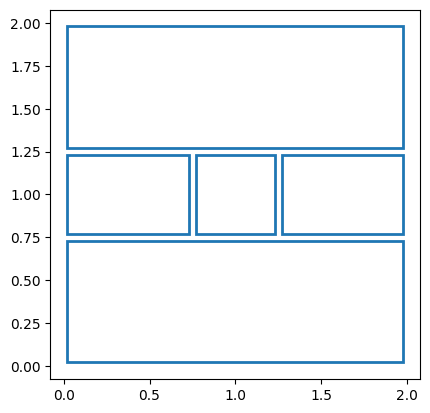

In [12]:
plot_rectangles(boxes_bounds_L,boxes_bounds_R)

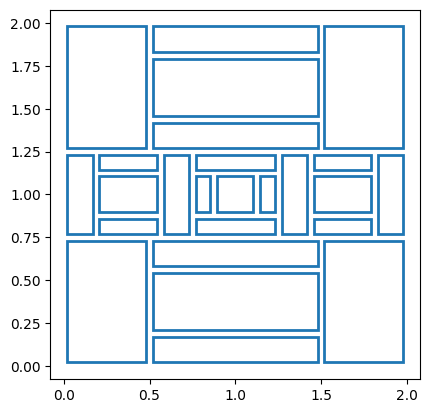

In [11]:
plot_rectangles(boxes_bounds_L_out,boxes_bounds_R_out)

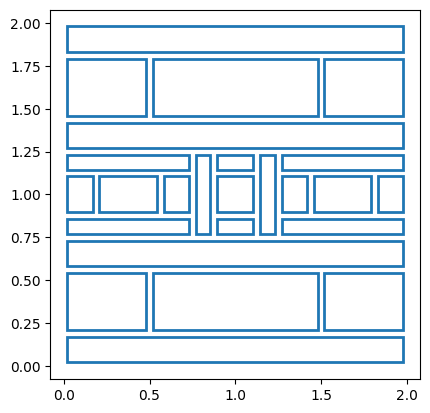

In [14]:
plot_rectangles(boxes_bounds_L_out,boxes_bounds_R_out)